# Corrective RAG (CRAG)

Corrective-RAG (CRAG) is a strategy for RAG that incorporates self-reflection / self-grading on retrieved documents.

In the paper here, a few steps are taken:

If at least one document exceeds the threshold for relevance, then it proceeds to generation
    Before generation, it performs knowledge refinement
    This partitions the document into "knowledge strips"
    It grades each strip, and filters our irrelevant ones
    If all documents fall below the relevance threshold or if the grader is unsure, then the framework seeks an additional datasource
    It will use web search to supplement retrieval

We will implement some of these ideas from scratch using LangGraph:
    Let's skip the knowledge refinement phase as a first pass. This can be added back as a node, if desired.
    If any documents are irrelevant, let's opt to supplement retrieval with web search.
    We'll use Tavily Search for web search.
    Let's use query re-writing to optimize the query for web search.

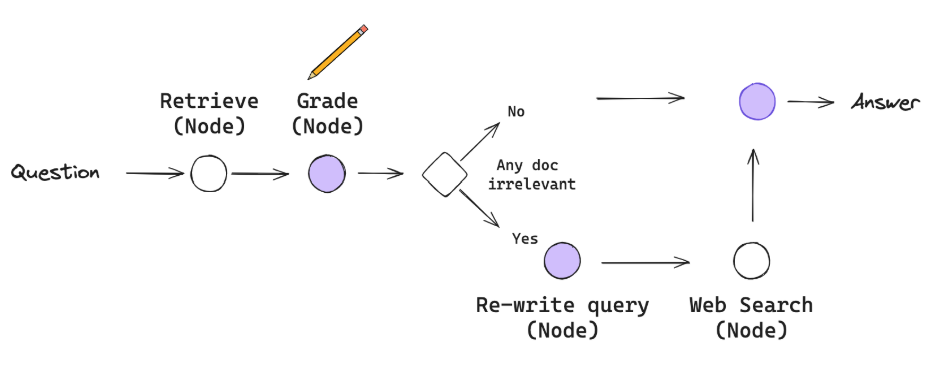

## Env Setup

In [6]:
from dotenv import load_dotenv
import os

In [7]:
load_dotenv()

LANGSMITH_API_KEY  = os.getenv("LANGSMITH_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [8]:
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = LANGSMITH_API_KEY
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY

## Indexing

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=0)
doc_splits = text_splitter.split_documents(docs_list)

vectorstore = Chroma.from_documents(
    documents=doc_splits, 
    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"), 
    collection_name="rag-chroma"
    )

retriever = vectorstore.as_retriever()

GoogleGenerativeAIError: Error embedding content: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 0 [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/embed_content_free_tier_requests"
  quota_id: "EmbedContentRequestsPerMinutePerUserPerProjectPerModel-FreeTier"
}
]

: 